In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_amb.mat to dataset_amb.mat
Saving dataset_elec.mat to dataset_elec.mat


In [8]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. LOAD AND PREPARE DATA
elec = scipy.io.loadmat('dataset_elec.mat')
amb = scipy.io.loadmat('dataset_amb.mat')

# Combine keys into a single DataFrame
df = pd.DataFrame({
    'idc1': elec['idc1'].flatten(),
    'idc2': elec['idc2'].flatten(),
    'vdc1': elec['vdc1'].flatten(),
    'vdc2': elec['vdc2'].flatten(),
    'irr': amb['irr'].flatten(),
    'label': amb['f_nv'].flatten() # Fault label (4 = Shading)
})


In [9]:
# Assign Day Index (assuming 16 days of data)
samples_per_day = len(df) // 16
df['day'] = (df.index // samples_per_day) + 1

# 2. FILTER: Only use days 1-7 and day 10
valid_days = [1, 2, 3, 4, 5, 6, 7, 10]
df_filtered = df[df['day'].isin(valid_days)].copy()

In [10]:
# 3. FEATURE ENGINEERING
# Calculate differences between strings
df_filtered['v_diff'] = np.abs(df_filtered['vdc1'] - df_filtered['vdc2'])
df_filtered['i_diff'] = np.abs(df_filtered['idc1'] - df_filtered['idc2'])

# Rolling variance identifies the "flicker" of dynamic shading
# Window of 30 samples is approx 30 seconds if frequency is 1Hz
df_filtered['i_var'] = df_filtered.groupby('day')['idc1'].transform(
    lambda x: x.rolling(window=30, center=True).var()
)
df_filtered = df_filtered.dropna()

In [11]:
# 4. TARGET DEFINITION
# 0 = Normal, 1 = Static, 2 = Dynamic
shading_mask = (df_filtered['label'] == 4)
var_threshold = df_filtered.loc[shading_mask, 'i_var'].median()

df_filtered['target'] = 0
df_filtered.loc[shading_mask & (df_filtered['i_var'] <= var_threshold), 'target'] = 1
df_filtered.loc[shading_mask & (df_filtered['i_var'] > var_threshold), 'target'] = 2

In [12]:
# 5. TRAIN MODEL
features = ['irr', 'idc1', 'idc2', 'vdc1', 'vdc2', 'v_diff', 'i_diff', 'i_var']
# Training on days 1-5, testing on the rest
train_mask = df_filtered['day'].isin([1, 2, 3, 4, 5])
X_train = df_filtered.loc[train_mask, features]
y_train = df_filtered.loc[train_mask, 'target']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# Add predictions back for the visualization
df_filtered['predicted'] = model.predict(df_filtered[features])

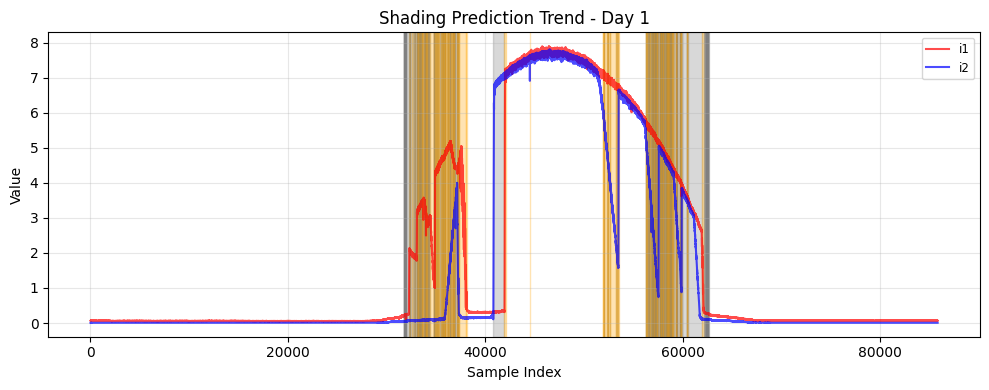

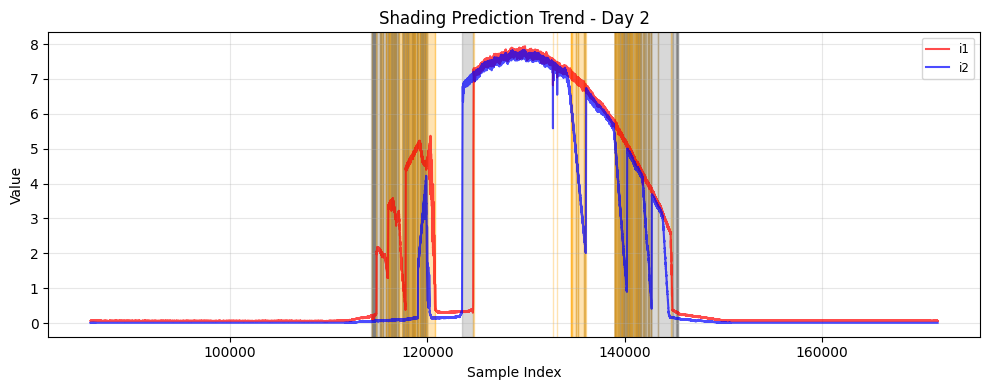

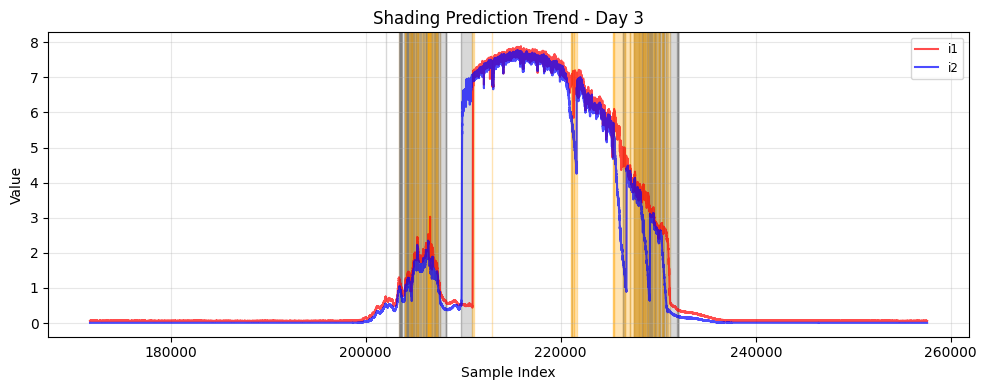

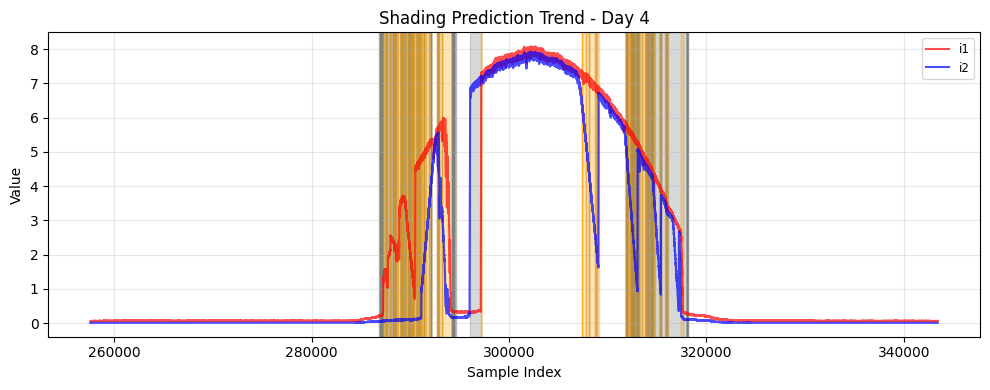

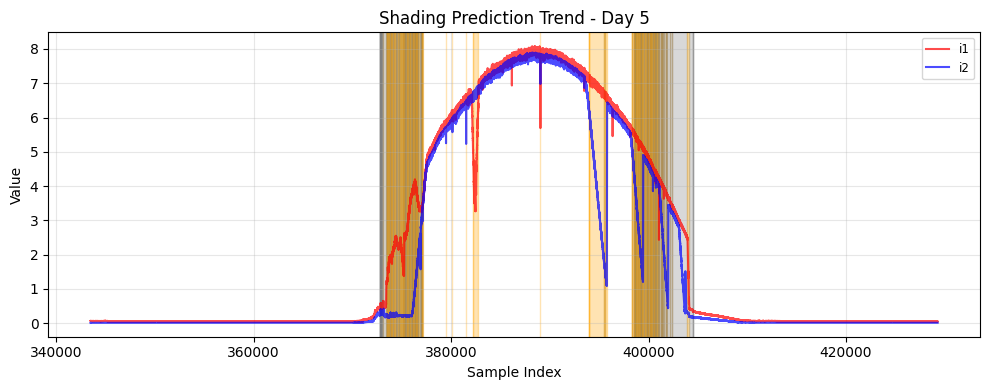

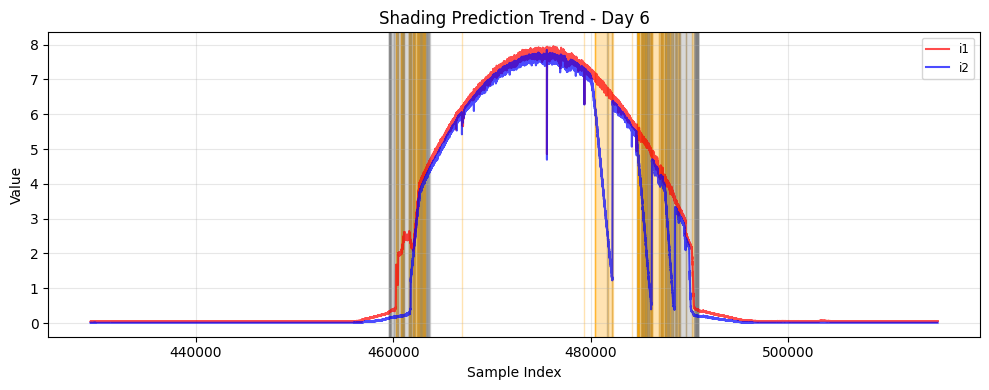

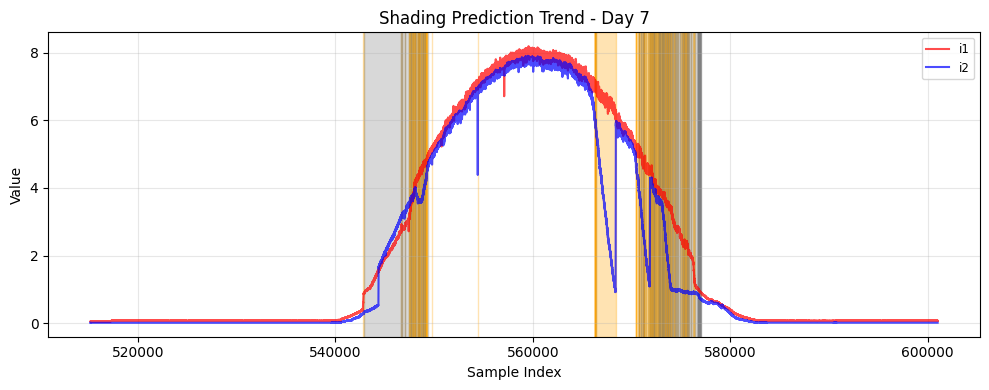

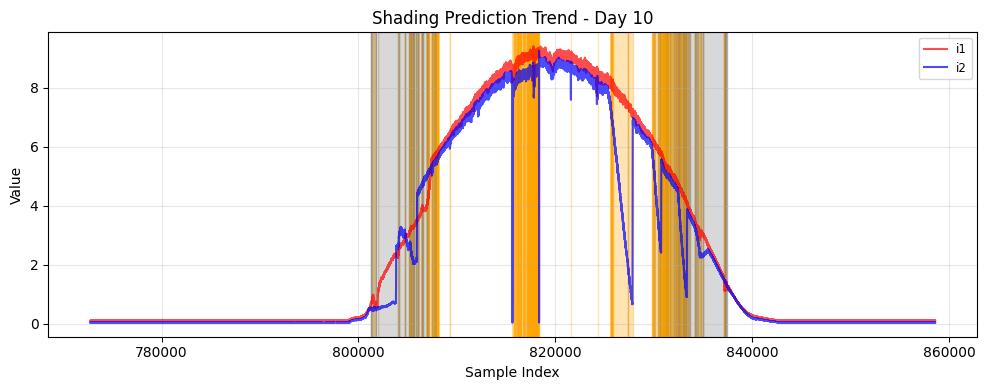

In [14]:
# 6. VISUALIZATION FUNCTION
def highlight_shadowing(day_data, ax):
    pred = day_data['predicted'].values
    indices = day_data.index.values
    # Detect where shading predictions start and end
    changes = np.where(np.diff(pred) != 0)[0] + 1
    start = 0
    for end in list(changes) + [len(pred)]:
        val = pred[start]
        if val == 1: # Static Shading
            ax.axvspan(indices[start], indices[min(end, len(indices)-1)], color='gray', alpha=0.3)
        elif val == 2: # Dynamic Shading
            ax.axvspan(indices[start], indices[min(end, len(indices)-1)], color='orange', alpha=0.3)
        start = end

# 7. GENERATE THE PLOTS
for day_num in valid_days:
    day_plot_data = df_filtered[df_filtered['day'] == day_num]

    plt.figure(figsize=(10, 4))
    ax = plt.gca()

    # Plotting Irradiance (scaled x200 for visibility) and Voltages
    #plt.plot(day_plot_data.index, day_plot_data['irr']*200, color='yellow', label='Irradiance (Scaled)')
    plt.plot(day_plot_data.index, day_plot_data['idc1'], color='red', label='i1', alpha=0.7)
    plt.plot(day_plot_data.index, day_plot_data['idc2'], color='blue', label='i2', alpha=0.7)

    highlight_shadowing(day_plot_data, ax)

    plt.title(f'Shading Prediction Trend - Day {day_num}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.3)

    # Fix legend duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

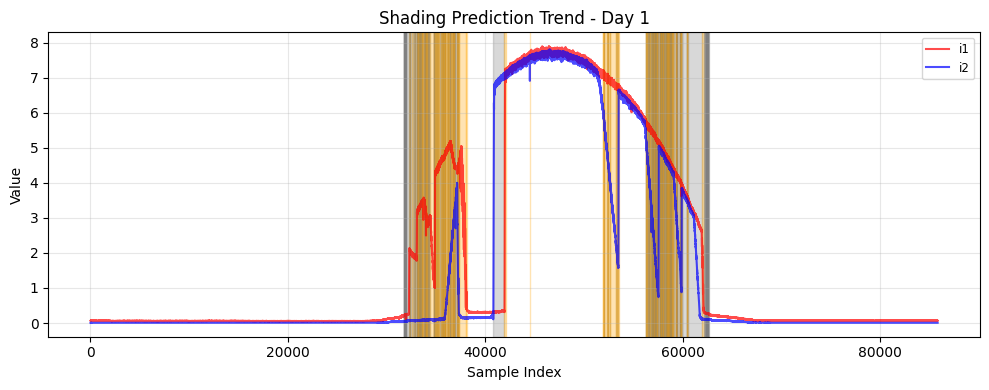

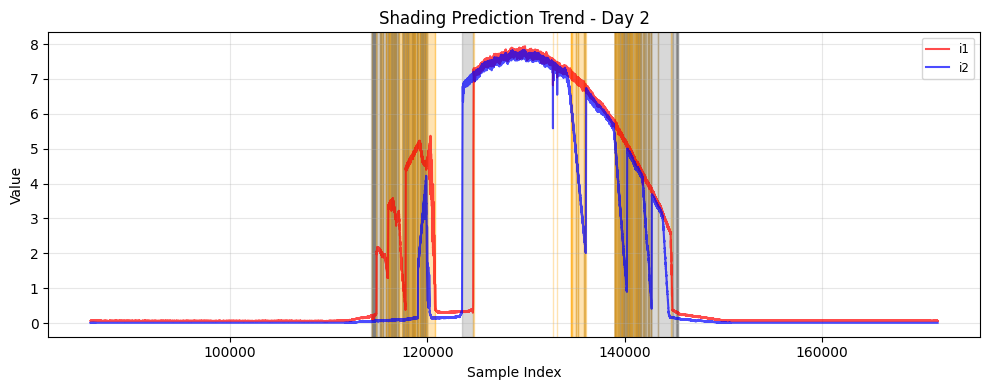

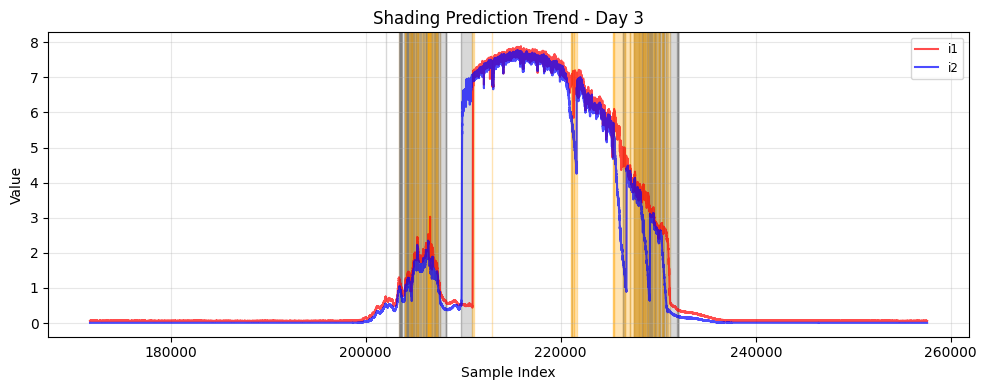

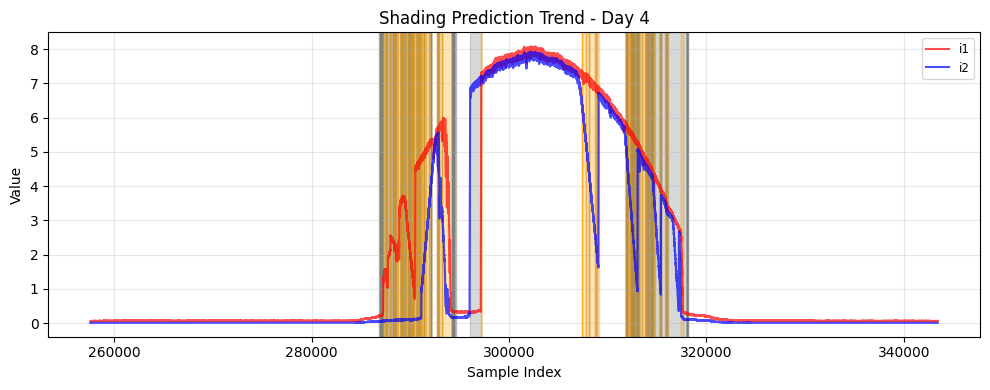

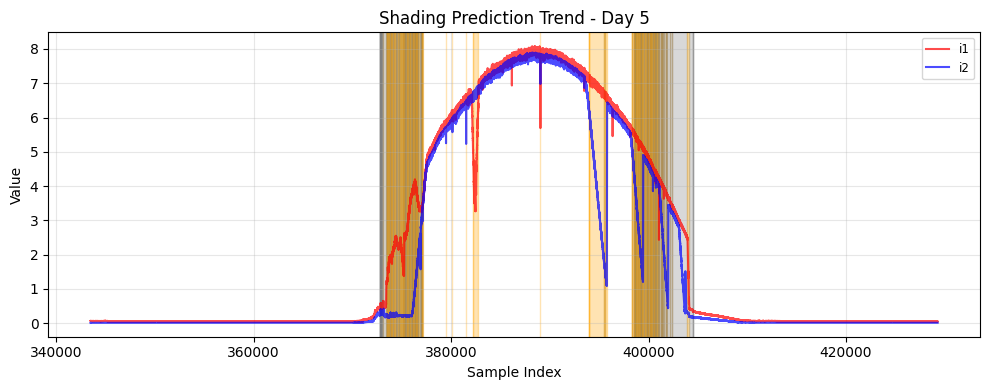

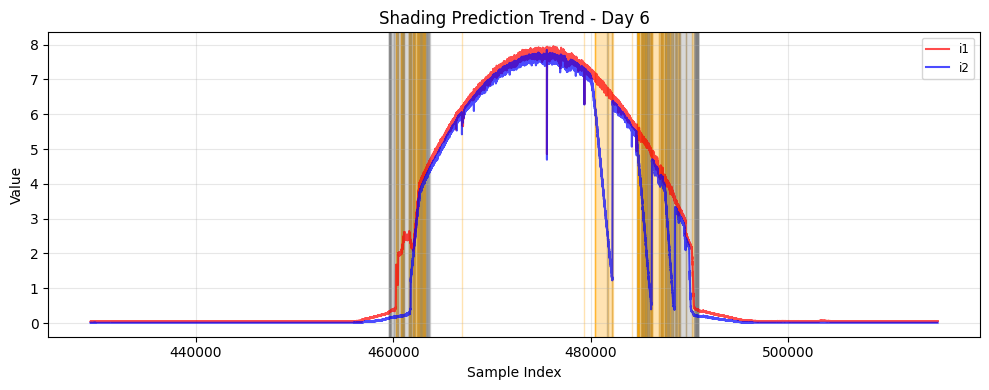

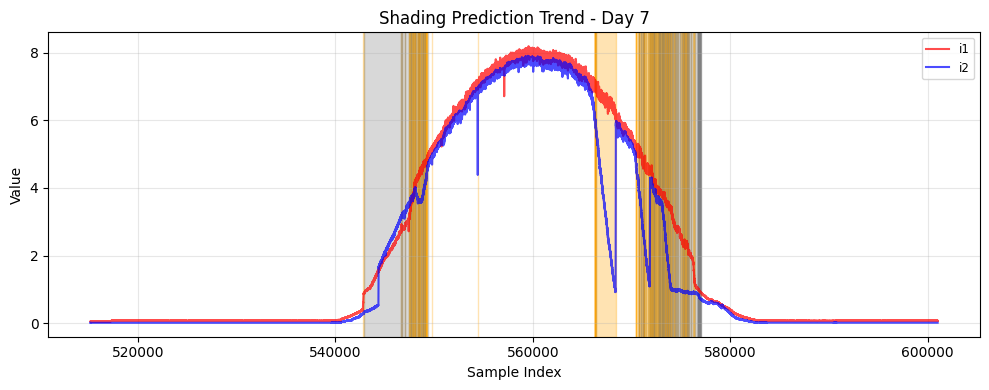

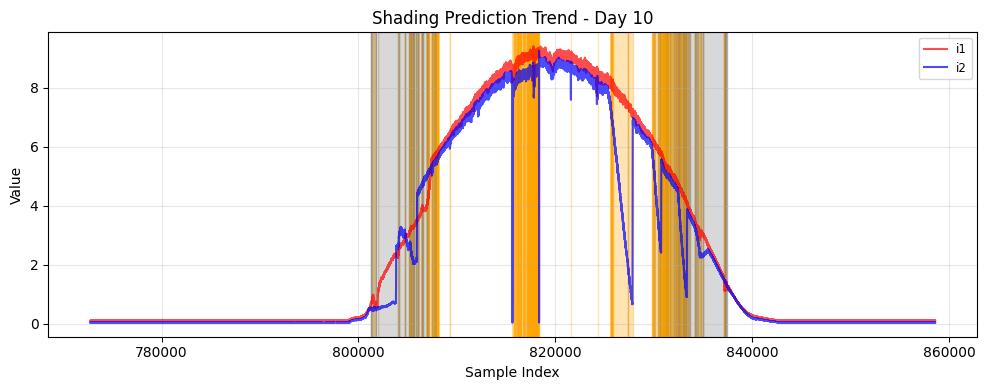

In [7]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. LOAD AND PREPARE DATA
# Ensure these files are in your current working directory
elec = scipy.io.loadmat('dataset_elec.mat')
amb = scipy.io.loadmat('dataset_amb.mat')

# Combine keys into a single DataFrame
df = pd.DataFrame({
    'idc1': elec['idc1'].flatten(),
    'idc2': elec['idc2'].flatten(),
    'vdc1': elec['vdc1'].flatten(),
    'vdc2': elec['vdc2'].flatten(),
    'irr': amb['irr'].flatten(),
    'label': amb['f_nv'].flatten() # Fault label (4 = Shading)
})

# Assign Day Index (assuming 16 days of data)
samples_per_day = len(df) // 16
df['day'] = (df.index // samples_per_day) + 1

# 2. FILTER: Only use days 1-7 and day 10
valid_days = [1, 2, 3, 4, 5, 6, 7, 10]
df_filtered = df[df['day'].isin(valid_days)].copy()

# 3. FEATURE ENGINEERING
# Calculate differences between strings
df_filtered['v_diff'] = np.abs(df_filtered['vdc1'] - df_filtered['vdc2'])
df_filtered['i_diff'] = np.abs(df_filtered['idc1'] - df_filtered['idc2'])

# Rolling variance identifies the "flicker" of dynamic shading
# Window of 30 samples is approx 30 seconds if frequency is 1Hz
df_filtered['i_var'] = df_filtered.groupby('day')['idc1'].transform(
    lambda x: x.rolling(window=30, center=True).var()
)
df_filtered = df_filtered.dropna()

# 4. TARGET DEFINITION
# 0 = Normal, 1 = Static, 2 = Dynamic
shading_mask = (df_filtered['label'] == 4)
var_threshold = df_filtered.loc[shading_mask, 'i_var'].median()

df_filtered['target'] = 0
df_filtered.loc[shading_mask & (df_filtered['i_var'] <= var_threshold), 'target'] = 1
df_filtered.loc[shading_mask & (df_filtered['i_var'] > var_threshold), 'target'] = 2

# 5. TRAIN MODEL
features = ['irr', 'idc1', 'idc2', 'vdc1', 'vdc2', 'v_diff', 'i_diff', 'i_var']
# Training on days 1-5, testing on the rest
train_mask = df_filtered['day'].isin([1, 2, 3, 4, 5])
X_train = df_filtered.loc[train_mask, features]
y_train = df_filtered.loc[train_mask, 'target']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Add predictions back for the visualization
df_filtered['predicted'] = model.predict(df_filtered[features])

# 6. VISUALIZATION FUNCTION
def highlight_shadowing(day_data, ax):
    pred = day_data['predicted'].values
    indices = day_data.index.values
    # Detect where shading predictions start and end
    changes = np.where(np.diff(pred) != 0)[0] + 1
    start = 0
    for end in list(changes) + [len(pred)]:
        val = pred[start]
        if val == 1: # Static Shading
            ax.axvspan(indices[start], indices[min(end, len(indices)-1)], color='gray', alpha=0.3)
        elif val == 2: # Dynamic Shading
            ax.axvspan(indices[start], indices[min(end, len(indices)-1)], color='orange', alpha=0.3)
        start = end

# 7. GENERATE THE PLOTS
for day_num in valid_days:
    day_plot_data = df_filtered[df_filtered['day'] == day_num]

    plt.figure(figsize=(10, 4))
    ax = plt.gca()

    # Plotting Irradiance (scaled x200 for visibility) and Voltages
    #plt.plot(day_plot_data.index, day_plot_data['irr']*200, color='yellow', label='Irradiance (Scaled)')
    plt.plot(day_plot_data.index, day_plot_data['idc1'], color='red', label='i1', alpha=0.7)
    plt.plot(day_plot_data.index, day_plot_data['idc2'], color='blue', label='i2', alpha=0.7)

    highlight_shadowing(day_plot_data, ax)

    plt.title(f'Shading Prediction Trend - Day {day_num}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.3)

    # Fix legend duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def highlight_shadowing(day_data, ax):
    # Get predictions and indices
    pred = day_data['predicted'].values
    indices = day_data.index.values

    # Identify contiguous blocks of predictions to draw spans
    changes = np.where(np.diff(pred) != 0)[0] + 1
    start_idx = 0
    for end_idx in list(changes) + [len(pred)]:
        current_pred = pred[start_idx]
        # 1 = Static, 2 = Dynamic
        if current_pred == 1:
            ax.axvspan(indices[start_idx], indices[min(end_idx, len(indices)-1)],
                       color='gray', alpha=0.3, label='Static Shading')
        elif current_pred == 2:
            ax.axvspan(indices[start_idx], indices[min(end_idx, len(indices)-1)],
                       color='orange', alpha=0.3, label='Dynamic Shading')
        start_idx = end_idx

# Make predictions on the entire clean_df using the trained model
# Ensure 'trained_model' and 'features' are available from the previous cell.
# If the previous cell (jxrUz5wJCZk5) was executed, these should be in global scope.
if 'trained_model' in globals() and 'features' in globals():
    clean_df['predicted'] = trained_model.predict(clean_df[features])
else:
    print("Error: 'trained_model' or 'features' not found in global scope. Please ensure the previous cells were executed correctly.")
    # Optionally, you might want to stop execution or define a dummy 'predicted' column if this error occurs.

# Plotting Loop for Days 1-7 and 10
days_to_plot = [1, 2, 3, 4, 5, 6, 7, 10]
for day_num in days_to_plot:
    day_data = clean_df[clean_df['day'] == day_num]

    plt.figure(figsize=(12, 5))
    ax = plt.gca()

    # Plotting features
    # Note: Irr is scaled by 100 to be visible on the same Y-axis as Vdc (~300V)
    plt.plot(day_data.index, day_data['irr'] * 100, color='gold', label='Irradiance (x100)')
    plt.plot(day_data.index, day_data['vdc1'], color='red', label='String 1 Voltage', alpha=0.7)
    plt.plot(day_data.index, day_data['vdc2'], color='blue', label='String 2 Voltage', alpha=0.7)

    # Apply shading highlights
    highlight_shadowing(day_data, ax)

    plt.title(f'Predicted Shading Types - Day {day_num}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')

    # Cleanup legend (prevent duplicate labels)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()